# Identify dates to send to data viz team

In [1]:
import numpy as np
import sys
import os, sys
import matplotlib.pyplot as plt
import xarray as xr
#from xarray import open_mfadataset
import cartopy.crs as crs
import cartopy
from matplotlib.colors import LogNorm
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import cmocean
import matplotlib
#from pathlib import Path4
#edit 12/04
from pathlib import Path
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import pyplot as plt
import rasterio
from rasterio.plot import show
#try adding
#import cfunits
from pyschism.mesh import Hgrid
import pyschism
from matplotlib.image import imread
import cmcrameri.cm as ccm
from matplotlib.collections import PolyCollection
print("Modules imported!")


Modules imported!


In [2]:
#import Sienna's plotting library
#import schism_plot_lib_2026_04_11 as spl
import schism_plot_lib_2026_07_01 as spl
import time

In [3]:
dpi = 300
image_save_dpi = 500
proj_utm10 = 'EPSG:26910'

import matplotlib_inline
%matplotlib inline
%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
matplotlib.rcParams["figure.dpi"] = dpi
plt.rcParams['figure.dpi'] = dpi

In [4]:
fn = "/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/outputs_bc_all/"
run = spl.SchismOutput(output_folder=fn)


 Creating run object for results in /expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/outputs_bc_all/ ... 

Found 67548 netcdf files!
Found output for:
	 1 - horizontalSideVelX
	 2 - horizontalSideVelY
	 3 - horizontalVelX
	 4 - horizontalVelY
	 5 - hotstart
	 6 - out2d
	 7 - salinity
	 8 - salinityAtElement
	 9 - temperature
	 10 - temperatureAtElement
	 11 - verticalVelAtElement
	 12 - zCoordinates


In [5]:
# saltiest date at Emmaton is 2018-11-11 02:45:00 (91)
#biggest difference btwn x2 is 2019-01-01 (148)
fno=384
tpoint=39 #39 is noon

In [6]:
# try new function from Lily
import xarray as xr
from dateutil.parser import parse

def read_nc(nc_file_path):
    """
    Reads a NetCDF file and returns an xarray Dataset.

    Parameters:
    nc_file_path (str): Path to the NetCDF file.

    Returns:
    xarray.Dataset: The dataset read from the NetCDF file.
    """
    ds = xr.open_dataset(nc_file_path, decode_times=False)
    origin = parse(ds.time.attrs["units"].split("since", 1)[1].strip(), ignoretz=True) # removes the timezone info from the origin timestring
    ds.time.attrs["units"] = f"seconds since {origin.isoformat()}"
    ds = xr.decode_cf(ds)

    return ds

In [7]:
# test=read_nc("/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/outputs_nudging/salinity_1.nc")
# test

In [8]:
hgrid = Hgrid.open('/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/hgrid_clean.gr3', crs=proj_utm10)

In [9]:
ds = run.Result(run, variable = "salinity", filenumber=fno)

/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/outputs_bc_all/salinity_384.nc
Loading in /expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/outputs_bc_all/salinity_384.nc


/home/jisrael/miniconda/envs/geoplot/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Loaded in dataset! 

<xarray.Dataset> Size: 2GB
Dimensions:   (time: 48, nSCHISM_hgrid_node: 468236, nSCHISM_vgrid_layers: 23)
Coordinates:
  * time      (time) datetime64[ns] 384B 2019-09-01T00:30:00 ... 2019-09-02
Dimensions without coordinates: nSCHISM_hgrid_node, nSCHISM_vgrid_layers
Data variables:
    salinity  (time, nSCHISM_hgrid_node, nSCHISM_vgrid_layers) float32 2GB ...
TIME ['2019-09-01T00:30:00.000000000' '2019-09-01T01:00:00.000000000'
 '2019-09-01T01:30:00.000000000' '2019-09-01T02:00:00.000000000'
 '2019-09-01T02:30:00.000000000' '2019-09-01T03:00:00.000000000'
 '2019-09-01T03:30:00.000000000' '2019-09-01T04:00:00.000000000'
 '2019-09-01T04:30:00.000000000' '2019-09-01T05:00:00.000000000'
 '2019-09-01T05:30:00.000000000' '2019-09-01T06:00:00.000000000'
 '2019-09-01T06:30:00.000000000' '2019-09-01T07:00:00.000000000'
 '2019-09-01T07:30:00.000000000' '2019-09-01T08:00:00.000000000'
 '2019-09-01T08:30:00.000000000' '2019-09-01T09:00:00.000000000'
 '2019-09-01T09:30:00.0000

Taking slice at time  ... 
Model is at time = Sep 01 2019, 20:00
Taking depth average ... 
dryFlagNode unique values: [0. 1.]
dryFlagNode dtype: float32
dryFlagNode shape: (48, 468236)
  Nodes flagged 1 (dry): 4198452
  Nodes flagged 0 (wet): 18276876
  Other values:          0
Dry nodes: 78831 / 468236 (16.8%)
Dry triangles masked: 76377 / 272099
Dry quads masked:     13977 / 291518
Domain = South_Delta
/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3


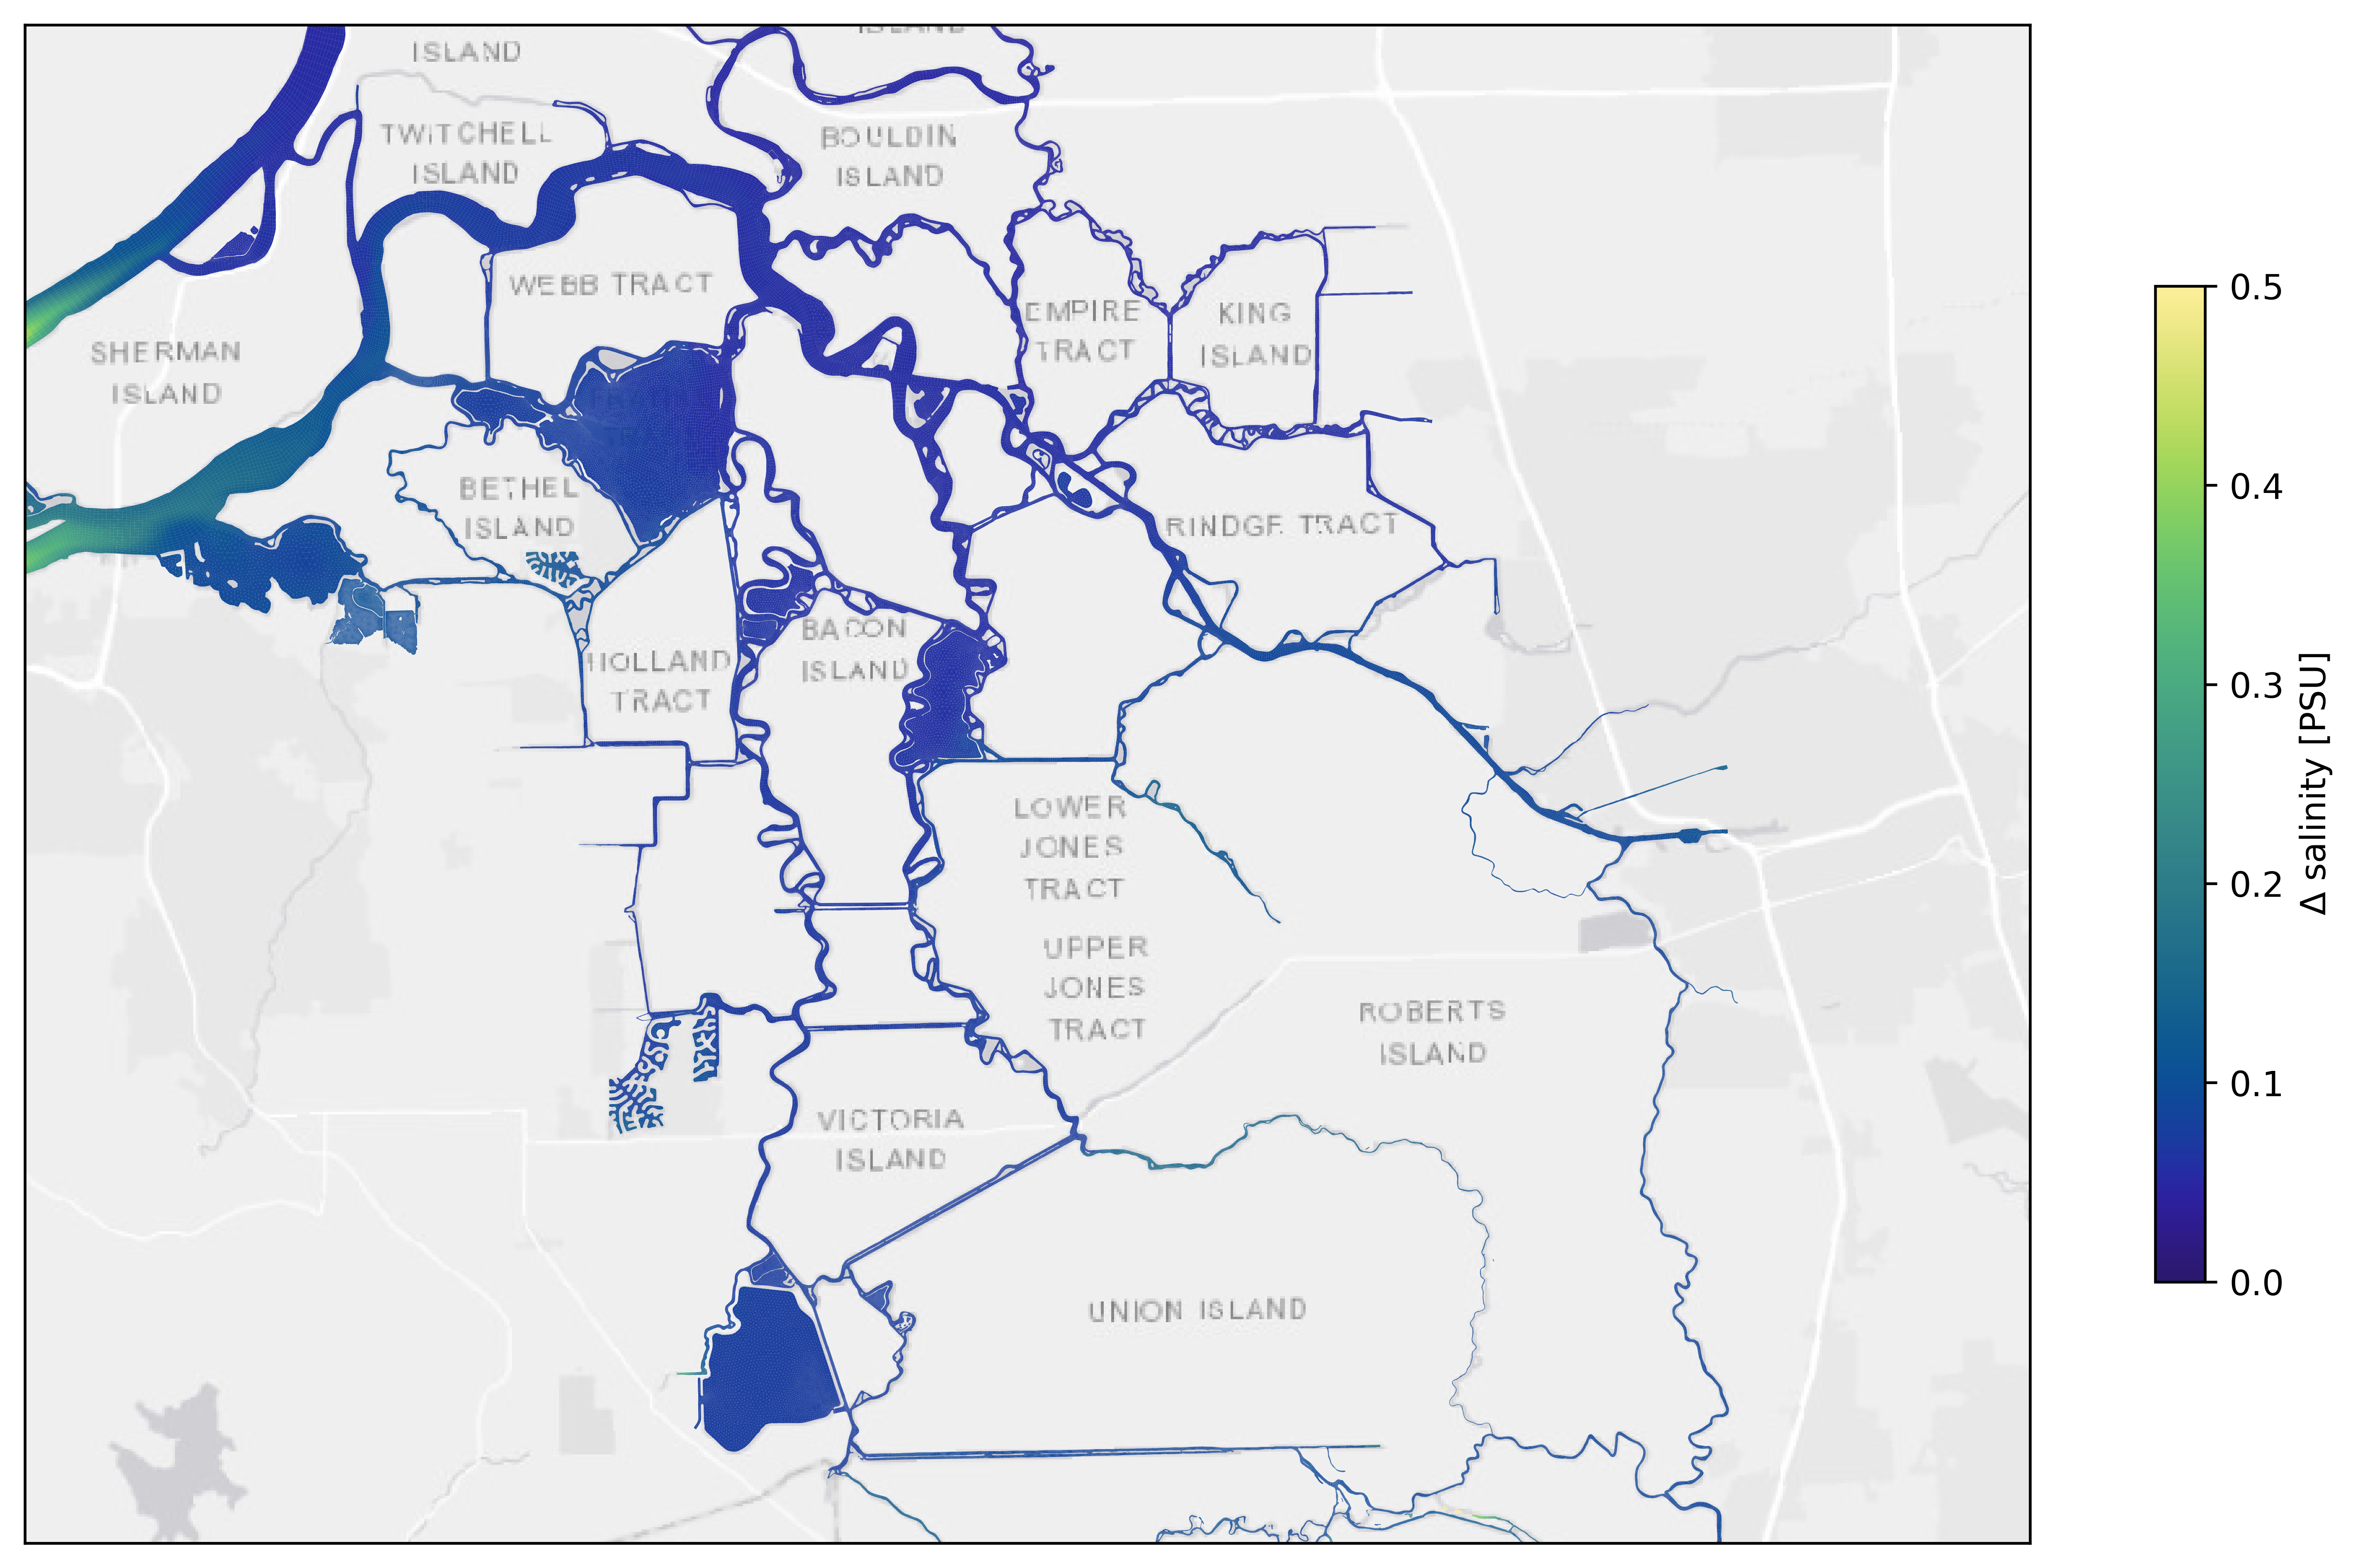

In [13]:
fig, ax = ds.plot_variable(run, domain="South_Delta", time=tpoint,depth= "average",
                                 titlestr="DCP - Baseline",climit=[0, 0.5],
                                 cmap=cmocean.cm.haline,cbar_label=r"$\Delta$ salinity [PSU]")